# Phase 2 — Explore the data

**Goal:** understand the data well enough to model it.

**Done when:** there are 5–6 clean charts and a list of what the forecast model must account for.

Sections
1. Which sensors to use
2. Where data is missing
3. CBD traffic over time
4. The shape of the day and the week
5. Weather and foot traffic
6. Sensor changes that aren't about people
7. What the model must account for

In [1]:
import duckdb
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

from melbourne_foot_traffic import config

con = duckdb.connect(str(config.DB_PATH), read_only=True)

# Chart style: thin marks, quiet axes, one colour per meaning
BLUE, ORANGE, AQUA, YELLOW = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
INK, INK2, MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e1e0d9"
BLUES = LinearSegmentedColormap.from_list(
    "blues", ["#fcfcfb", "#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"]
)
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": INK2,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlecolor": INK,
    "axes.titlelocation": "left", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "xtick.color": MUTED, "ytick.color": MUTED, "text.color": INK2,
    "lines.linewidth": 2, "font.size": 10, "figure.dpi": 110,
})

RECENT = ("2024-10-01", "2026-09-30")  # two full years from the live table

## 1. Which sensors to use

The council has 134 sensors, but they were installed at different times, some
moved, and not all are in the CBD. For a fair before/after comparison we need
sensors that **were counting in 2019 and are still counting now, in the same place**.

Rules:
- inside the CBD grid (Flinders St to La Trobe St, Spencer St to Spring St);
- at least 90% of hours present in 2019 **and** in Oct 2024 – Sep 2026;
- not moved or changed to count something different (from the council's notes).

In [2]:
coverage = con.sql(f'''
    WITH cov AS (
        SELECT sensor_id,
            count(*) FILTER (WHERE year(date) = 2019) / 8760.0                         AS cov_2019,
            count(*) FILTER (WHERE date BETWEEN '{RECENT[0]}' AND '{RECENT[1]}') / (730 * 24.0) AS cov_recent,
            avg(count) FILTER (WHERE year(date) = 2019)                                AS mean_2019,
            avg(count) FILTER (WHERE date BETWEEN '{RECENT[0]}' AND '{RECENT[1]}')     AS mean_recent
        FROM counts GROUP BY sensor_id
    )
    SELECT c.*, c.mean_recent / c.mean_2019 AS recent_vs_2019,
           s.sensor_description AS name, s.latitude, s.longitude, s.note
    FROM cov c JOIN sensors s ON s.location_id = c.sensor_id
''').df()

in_cbd = coverage.latitude.between(-37.8200, -37.8090) & coverage.longitude.between(144.9520, 144.9745)
well_covered = (coverage.cov_2019 >= 0.9) & (coverage.cov_recent >= 0.9)
# Excluded after reading the council's notes:
#   6  renamed "Flinders Underpass - Myki Barriers" (now counts a different spot)
#   47 "moved to 250 Elizabeth Street"
MOVED_OR_CHANGED = [6, 47]

candidates = coverage[in_cbd & well_covered].sort_values("sensor_id")
selected = candidates[~candidates.sensor_id.isin(MOVED_OR_CHANGED)]
SENSORS = selected.sensor_id.tolist()

print(f"{len(candidates)} CBD sensors are well covered; {len(SENSORS)} kept after removing moved/changed ones")
selected[["sensor_id", "name", "cov_2019", "cov_recent", "recent_vs_2019", "note"]].round(2)

20 CBD sensors are well covered; 18 kept after removing moved/changed ones


,sensor_id,name,cov_2019,cov_recent,recent_vs_2019,note
72,2,Bourke Street Mall (South),0.97,1.00,0.66,NaN
0,3,Melbourne Central,0.91,1.00,0.92,NaN
42,4,Town Hall (West),1.00,0.99,1.07,NaN
1,5,Princes Bridge,1.00,1.00,0.89,Replace with: 00:6e:02:01:9e:54
45,17,Collins Place (South),0.93,1.00,0.76,Device upgraded in 26/02/2020
6,18,Collins Place (North),1.00,0.93,0.66,NaN
7,19,Chinatown-Swanston St (North),1.00,0.98,0.92,"Pushbox Upgrade, 20/07/2023"
8,20,Chinatown-Lt Bourke St (South),1.00,1.00,0.84,"Pushbox Upgrade, 20/07/2023"
74,21,155-161 Russell Street,1.00,1.00,0.62,NaN
75,23,Spencer St-Collins St (South),1.00,1.00,0.87,"Pushbox Upgrade, 25/07/2023"


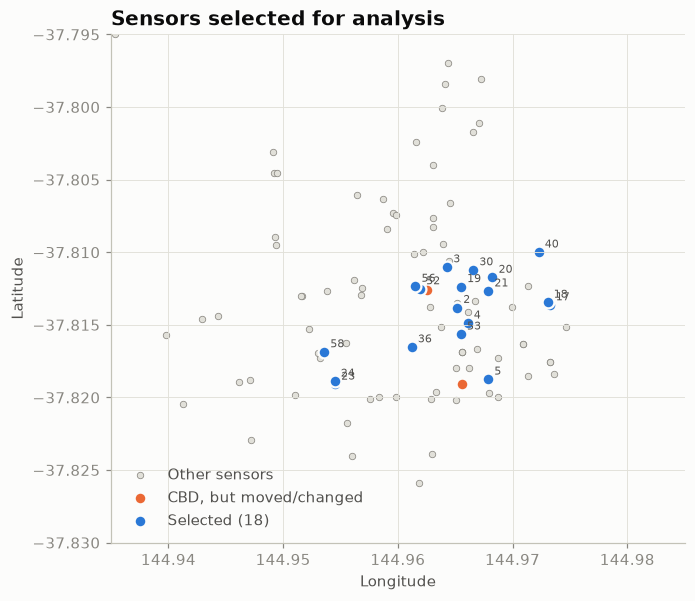

In [3]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(coverage.longitude, coverage.latitude, s=18, color=GRID, edgecolor=MUTED, linewidth=0.5, label="Other sensors")
moved = coverage[coverage.sensor_id.isin(MOVED_OR_CHANGED)]
ax.scatter(moved.longitude, moved.latitude, s=60, color=ORANGE, edgecolor="#fcfcfb", linewidth=1.5, label="CBD, but moved/changed")
ax.scatter(selected.longitude, selected.latitude, s=60, color=BLUE, edgecolor="#fcfcfb", linewidth=1.5, label=f"Selected ({len(SENSORS)})")
for _, r in selected.iterrows():
    ax.annotate(str(r.sensor_id), (r.longitude, r.latitude), xytext=(4, 3), textcoords="offset points", fontsize=7, color=INK2)
ax.set_xlim(144.935, 144.985); ax.set_ylim(-37.830, -37.795)
ax.ticklabel_format(useOffset=False)
ax.set_aspect(1 / np.cos(np.radians(37.81)))
ax.set_title("Sensors selected for analysis")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.legend(frameon=False, loc="lower left")
plt.show()

## 2. Where data is missing

Each row is a sensor, each column a month. Darker = more of that month's hours
have a count. White = no data at all.

Remember: **a missing hour is not a zero.** A row with `count = 0` means the sensor
worked and nobody walked past; no row means we don't know.

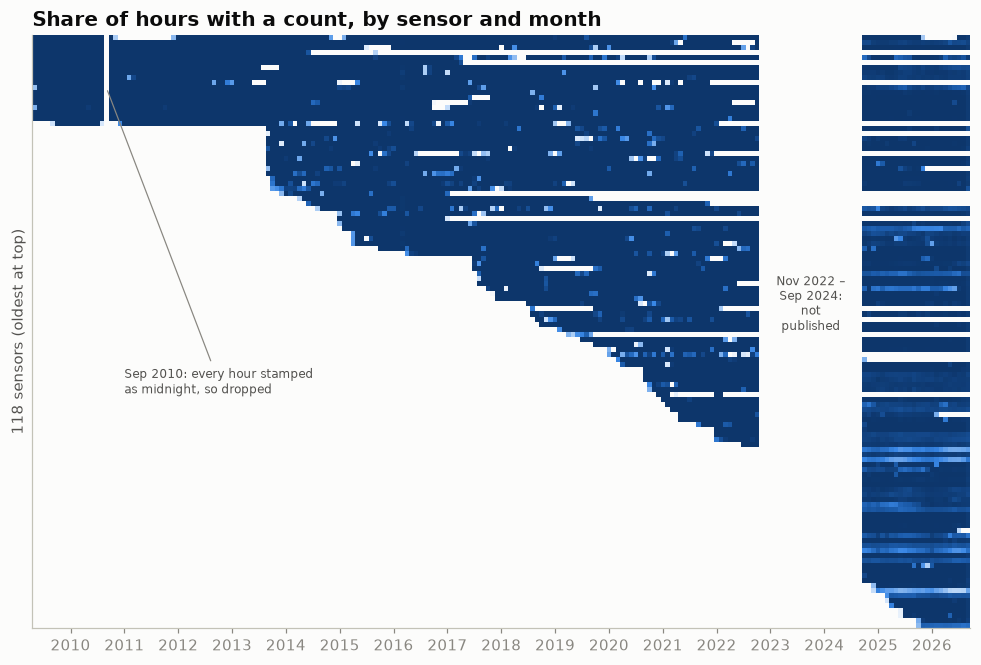

In [4]:
monthly = con.sql('''
    SELECT sensor_id, date_trunc('month', date) AS month, count(*) AS hours
    FROM counts GROUP BY ALL
''').df()
monthly["share"] = monthly.hours / (monthly.month.dt.days_in_month * 24)
months = pd.date_range("2009-05-01", "2026-09-01", freq="MS")
grid = monthly.pivot(index="sensor_id", columns="month", values="share").reindex(columns=months)
grid = grid.loc[grid.notna().idxmax(axis=1).sort_values().index]  # oldest sensors at the top

fig, ax = plt.subplots(figsize=(11, 7))
ax.imshow(grid.fillna(0).clip(0, 1).values, aspect="auto", cmap=BLUES, vmin=0, vmax=1, interpolation="nearest")
ax.grid(False)
year_ticks = [i for i, m in enumerate(months) if m.month == 1]
ax.set_xticks(year_ticks, [months[i].year for i in year_ticks])
ax.set_yticks([])
ax.set_ylabel(f"{len(grid)} sensors (oldest at top)")
ax.set_title("Share of hours with a count, by sensor and month")
gap_mid = (months.get_loc(pd.Timestamp("2022-11-01")) + months.get_loc(pd.Timestamp("2024-09-01"))) / 2
ax.text(gap_mid, len(grid) * 0.45, "Nov 2022 –\nSep 2024:\nnot\npublished", ha="center", va="center", fontsize=8, color=INK2)
ax.annotate("Sep 2010: every hour stamped\nas midnight, so dropped",
            xy=(months.get_loc(pd.Timestamp("2010-09-01")), 10), xytext=(20, len(grid) * 0.6),
            fontsize=8, color=INK2, arrowprops=dict(arrowstyle="-", color=MUTED, lw=0.8))
plt.show()

In [5]:
# Zeros vs missing: days where a selected sensor reported zero for every daytime hour
# (more likely a dead sensor than an empty city)
con.sql(f'''
    SELECT sensor_id, count(*) AS suspicious_days
    FROM (
        SELECT sensor_id, date
        FROM counts
        WHERE hour BETWEEN 8 AND 20 AND sensor_id IN ({",".join(map(str, SENSORS))})
        GROUP BY ALL
        HAVING count(*) >= 10 AND max(count) = 0
    )
    GROUP BY ALL ORDER BY suspicious_days DESC
''').df()

,sensor_id,suspicious_days
0,52,20
1,19,16


## 3. CBD traffic over time

Average hourly count across the selected sensors, indexed so that 2019 = 100,
smoothed over 4 weeks.

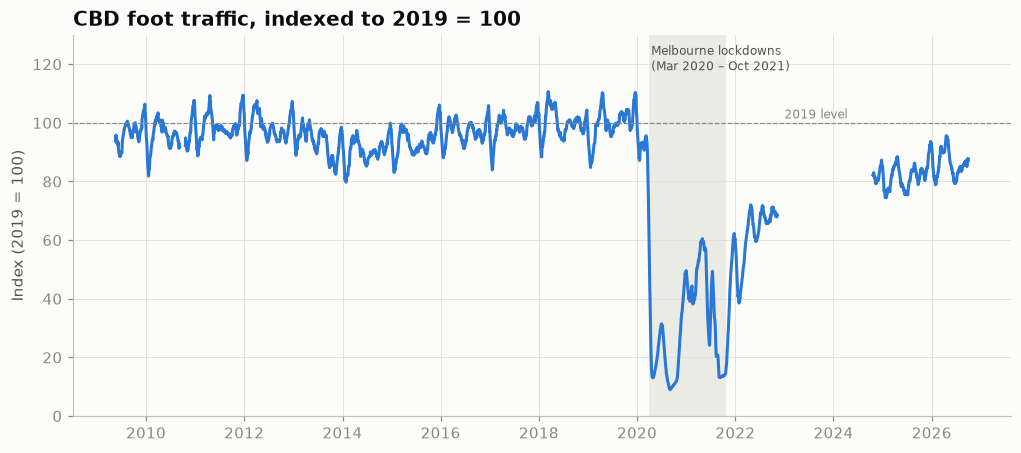

Average index by year:
date
2009     97.0
2010     96.0
2011     99.0
2012     98.0
2013     93.0
2014     90.0
2015     94.0
2016     97.0
2017     98.0
2018    100.0
2019    100.0
2020     37.0
2021     39.0
2022     62.0
2024     83.0
2025     82.0
2026     86.0


In [6]:
# Index each sensor to its own 2019 average first, then average across sensors.
# (Averaging raw counts would mislead: in 2009 only a few of these sensors existed,
#  and they happen to be the busiest ones.)
daily = con.sql(f'''
    WITH base AS (
        SELECT sensor_id, avg(count) AS mean_2019
        FROM counts WHERE year(date) = 2019 GROUP BY sensor_id
    ),
    per_sensor AS (
        SELECT c.sensor_id, c.date, 100 * avg(c.count) / b.mean_2019 AS idx
        FROM counts c JOIN base b USING (sensor_id)
        WHERE c.sensor_id IN ({",".join(map(str, SENSORS))})
        GROUP BY c.sensor_id, c.date, b.mean_2019
        HAVING count(*) = 24          -- full days only
    )
    SELECT date, avg(idx) AS "index", count(*) AS sensors
    FROM per_sensor GROUP BY date ORDER BY date
''').df().set_index("date")
daily.index = pd.to_datetime(daily.index)
# Reindex to every day so gaps stay gaps instead of being bridged by a line
smooth = daily["index"].asfreq("D").rolling(28, min_periods=20).mean()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.axvspan(pd.Timestamp("2020-03-30"), pd.Timestamp("2021-10-22"), color=GRID, alpha=0.6, lw=0)
ax.text(pd.Timestamp("2020-04-15"), 127, "Melbourne lockdowns\n(Mar 2020 – Oct 2021)", fontsize=8, color=INK2, va="top")
ax.plot(smooth.index, smooth.values, color=BLUE)
ax.axhline(100, color=MUTED, lw=0.8, ls="--")
ax.text(pd.Timestamp("2023-01-01"), 101.5, "2019 level", fontsize=8, color=MUTED)
ax.set_ylim(0, 130)
ax.set_title("CBD foot traffic, indexed to 2019 = 100")
ax.set_ylabel("Index (2019 = 100)")
ax.xaxis.set_major_locator(mdates.YearLocator(2)); ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.show()

print("Average index by year:")
print(daily["index"].groupby(daily.index.year).mean().round(0).to_string())

## 4. The shape of the day and the week

Average hourly profile, 2019 vs Oct 2024 – Sep 2026, for each type of day.
This is the first look at the Phase 4 question: has the work week changed shape?

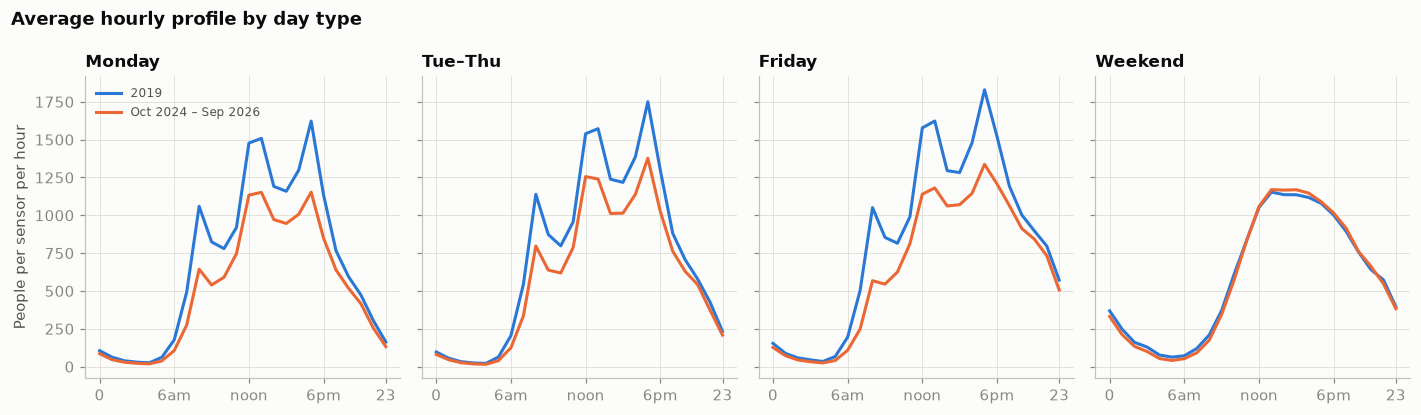

In [7]:
profiles = con.sql(f'''
    SELECT CASE WHEN year(date) = 2019 THEN '2019' ELSE 'recent' END AS period,
           CASE dayofweek(date) WHEN 1 THEN 'Monday' WHEN 5 THEN 'Friday'
                WHEN 0 THEN 'Weekend' WHEN 6 THEN 'Weekend' ELSE 'Tue–Thu' END AS day_type,
           hour, avg(count) AS mean_count
    FROM counts
    WHERE sensor_id IN ({",".join(map(str, SENSORS))})
      AND (year(date) = 2019 OR date BETWEEN '{RECENT[0]}' AND '{RECENT[1]}')
    GROUP BY ALL
''').df()

day_types = ["Monday", "Tue–Thu", "Friday", "Weekend"]
fig, axes = plt.subplots(1, 4, figsize=(13, 3.8), sharey=True)
for ax, dt in zip(axes, day_types):
    for period, colour, label in [("2019", BLUE, "2019"), ("recent", ORANGE, "Oct 2024 – Sep 2026")]:
        p = profiles[(profiles.day_type == dt) & (profiles.period == period)].sort_values("hour")
        ax.plot(p.hour, p.mean_count, color=colour, label=label)
    ax.set_title(dt, fontsize=11)
    ax.set_xticks([0, 6, 12, 18, 23], ["0", "6am", "noon", "6pm", "23"])
axes[0].set_ylabel("People per sensor per hour")
axes[0].legend(frameon=False, loc="upper left", fontsize=8)
fig.suptitle("Average hourly profile by day type", x=0.01, ha="left", fontweight="bold", color=INK)
fig.tight_layout()
plt.show()

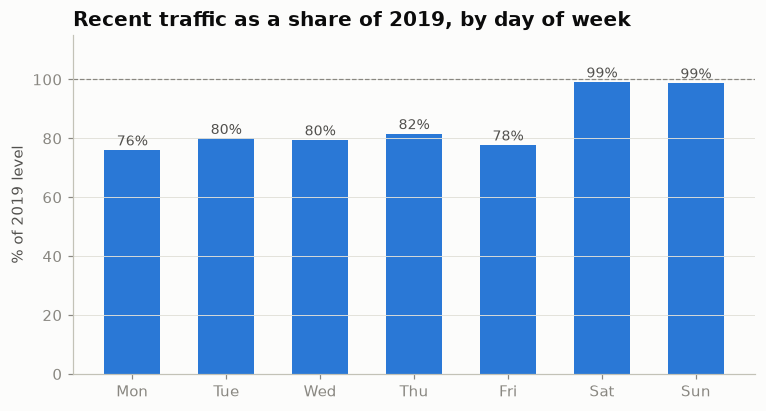

In [8]:
by_weekday = con.sql(f'''
    SELECT dayofweek(date) AS dow,
           avg(count) FILTER (WHERE year(date) = 2019) AS mean_2019,
           avg(count) FILTER (WHERE date BETWEEN '{RECENT[0]}' AND '{RECENT[1]}') AS mean_recent
    FROM counts
    WHERE sensor_id IN ({",".join(map(str, SENSORS))})
    GROUP BY dow
''').df()
order = [1, 2, 3, 4, 5, 6, 0]
names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
by_weekday = by_weekday.set_index("dow").loc[order]
by_weekday["pct_of_2019"] = 100 * by_weekday.mean_recent / by_weekday.mean_2019

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(names, by_weekday.pct_of_2019, color=BLUE, width=0.6)
ax.axhline(100, color=MUTED, lw=0.8, ls="--")
for b, v in zip(bars, by_weekday.pct_of_2019):
    ax.text(b.get_x() + b.get_width() / 2, v + 1.5, f"{v:.0f}%", ha="center", fontsize=9, color=INK2)
ax.set_ylim(0, 115)
ax.set_title("Recent traffic as a share of 2019, by day of week")
ax.set_ylabel("% of 2019 level")
ax.grid(axis="x", visible=False)
plt.show()

## 5. Weather and foot traffic

To isolate weather, each count is compared with what's *normal* for that sensor,
weekday and hour in the same period (the median). A value of 0.9 means 10% fewer
people than usual. Daytime hours (8am–8pm) only; lockdown years excluded.

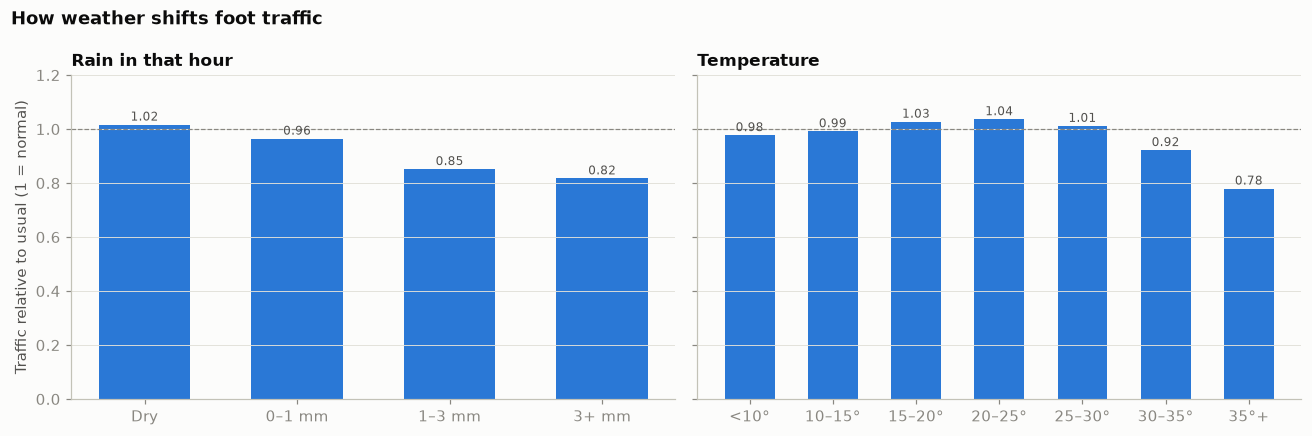

mean    size
rain        Dry     1.016  211733
            0–1 mm  0.964   35040
            1–3 mm  0.851    5234
            3+ mm   0.817    1037
temperature <10°    0.977   19072
            10–15°  0.991   85138
            15–20°  1.027   77767
            20–25°  1.036   41525
            25–30°  1.012   18200
            30–35°  0.922    7716
            35°+    0.779    3626

In [9]:
rel = con.sql(f'''
    WITH base AS (
        SELECT h.*, CASE WHEN year(date) = 2019 THEN '2019' ELSE 'recent' END AS period,
               dayofweek(date) AS dow
        FROM hourly h
        WHERE sensor_id IN ({",".join(map(str, SENSORS))}) AND hour BETWEEN 8 AND 20
          AND (year(date) = 2019 OR date BETWEEN '{RECENT[0]}' AND '{RECENT[1]}')
          AND temperature IS NOT NULL
    )
    SELECT *, count / NULLIF(median(count) OVER (PARTITION BY sensor_id, period, dow, hour), 0) AS relative
    FROM base
''').df()
rel = rel[rel.relative.notna()]

rel["rain"] = pd.cut(rel.precipitation_mm, [-0.01, 0, 1, 3, 100], labels=["Dry", "0–1 mm", "1–3 mm", "3+ mm"])
rel["temp"] = pd.cut(rel.temperature, [-5, 10, 15, 20, 25, 30, 35, 50],
                     labels=["<10°", "10–15°", "15–20°", "20–25°", "25–30°", "30–35°", "35°+"])
rain_fx = rel.groupby("rain", observed=True).relative.agg(["mean", "size"])
temp_fx = rel.groupby("temp", observed=True).relative.agg(["mean", "size"])

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, fx, title in [(a1, rain_fx, "Rain in that hour"), (a2, temp_fx, "Temperature")]:
    bars = ax.bar(fx.index.astype(str), fx["mean"], color=BLUE, width=0.6)
    ax.axhline(1, color=MUTED, lw=0.8, ls="--")
    for b, v in zip(bars, fx["mean"]):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.015, f"{v:.2f}", ha="center", fontsize=8, color=INK2)
    ax.set_title(title, fontsize=11)
    ax.grid(axis="x", visible=False)
a1.set_ylabel("Traffic relative to usual (1 = normal)")
a1.set_ylim(0, 1.2)
fig.suptitle("How weather shifts foot traffic", x=0.01, ha="left", fontweight="bold", color=INK)
fig.tight_layout()
plt.show()
pd.concat({"rain": rain_fx, "temperature": temp_fx}).round(3)

## 6. Sensor changes that aren't about people

A sudden, permanent step in one sensor while its neighbours stay flat usually
means the hardware or the location changed. Example: sensor 6 (Flinders St
underpass), which the council now describes as "Myki Barriers", compared with
sensor 4 (Town Hall West), 200 m away. Town Hall stays flat while sensor 6 jumps
up and down; the council's notes also say it was "upgraded on 8 Sep 2021".

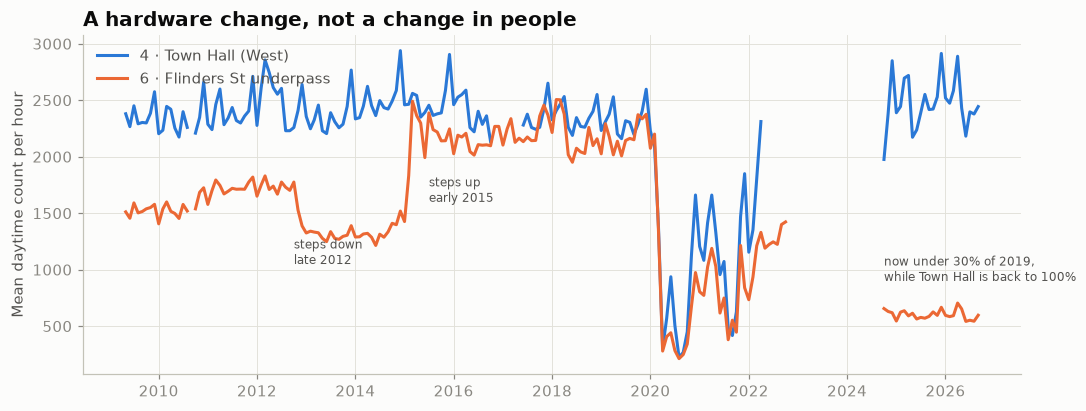

In [10]:
steps = con.sql('''
    SELECT sensor_id, date_trunc('month', date) AS month, avg(count) AS mean_count
    FROM counts WHERE sensor_id IN (4, 6) AND hour BETWEEN 8 AND 20
    GROUP BY ALL ORDER BY month
''').df()
fig, ax = plt.subplots(figsize=(11, 4))
for sid, colour, label in [(4, BLUE, "4 · Town Hall (West)"), (6, ORANGE, "6 · Flinders St underpass")]:
    s = steps[steps.sensor_id == sid].set_index("month").mean_count.asfreq("MS")
    ax.plot(s.index, s.values, color=colour, label=label)
for x, y, label in [("2012-10-01", 1050, "steps down\nlate 2012"), ("2015-07-01", 1600, "steps up\nearly 2015"),
                   ("2024-10-01", 900, "now under 30% of 2019,\nwhile Town Hall is back to 100%")]:
    ax.annotate(label, (pd.Timestamp(x), y), fontsize=8, color=INK2)
ax.set_title("A hardware change, not a change in people")
ax.set_ylabel("Mean daytime count per hour")
ax.legend(frameon=False, loc="upper left")
plt.show()

**The 2023 upgrades.** The council's notes say many CBD sensors got a
"Pushbox Upgrade" in July–August 2023, inside the data gap, so we can't see
whether it caused a step. One check: do upgraded and non-upgraded sensors show
similar recovery since 2019? If yes, the upgrade probably didn't shift counts much.

In [11]:
selected.assign(upgraded_2023=selected.note.fillna("").str.contains("Pushbox"))\
    .groupby("upgraded_2023").recent_vs_2019.agg(["mean", "median", "count"]).round(2)

,mean,median,count
upgraded_2023,,,
False,0.84,0.81,11
True,0.83,0.84,7


## 7. What the model must account for

*(data to Sep 2026)*

1. **Hour of day × day of week.** Strong daily cycle with commuter peaks at
   8am and 5pm on weekdays, a single midday hump on weekends.
2. **The post-COVID shift.** CBD traffic is about 85% of 2019. Weekends are
   fully back (~99%); weekdays are at 76–82%, lowest on Monday and Friday.
   The 8am commuter peak lost the most. A model trained on 2019 would
   over-predict weekdays: train on post-2022 data only.
3. **Sensor identity.** Sensors differ ~10× in volume; `sensor_id` must be a feature.
4. **Weather.** Rain cuts traffic by ~4% (light) to ~18% (3+ mm in the hour).
   Heat matters above 30°C: ~8% lower at 30–35°, ~22% lower at 35°+.
5. **Missing data.** No row ≠ zero. Some sensors report whole days of zeros
   (sensors 52 and 19), which look like faults: treat as missing.
6. **Hardware changes.** Step changes (e.g. sensor 6) are not real changes in
   people; sensors 6 and 47 excluded. 2023 upgrades fall in the data gap, but
   upgraded and non-upgraded sensors recovered similarly (0.83 vs 0.84), so
   they probably didn't shift counts much.
7. **Holidays and events** (not yet checked): public holidays, school terms,
   AFL Grand Final, Moomba. Phase 3 features.